# **Yes Bank Stock Closing Price Prediction**    -  **ML Regression**


##### **Project Type**    - Regression
##### **Contribution**    - Individual
##### **Team Member 1 -** Solo Contribution
##### **Author Name -** Janani M

# **Project Summary -**

Yes Bank's stock price has gone through an extraordinary journey — from a steady climb after its 2005 listing, to an explosive rally peaking at ₹367.90 in July 2018, to a severe and sustained crash following the fraud case involving founder Rana Kapoor, the subsequent RBI-led reconstruction and moratorium in March 2020, and the broader COVID-19 market downturn. This notebook builds on the exploratory analysis carried out in the companion EDA notebook to construct a Machine Learning regression model capable of predicting the monthly closing price (`Close`) of Yes Bank stock from its `Open`, `High`, and `Low` prices for that month.

The EDA had already revealed an extremely strong linear relationship between all four OHLC (Open-High-Low-Close) columns, with pairwise correlations consistently above 0.97. This is a very favourable starting point for regression modelling, and this notebook is structured to confirm and exploit that relationship in a rigorous, well-validated way rather than simply assuming it will hold.

The notebook begins with the standard "Know Your Data" and "Understanding Your Variables" sections (mirroring the EDA notebook briefly, for completeness), followed by the same 20-chart visual exploration used in the EDA notebook, then moves into a dedicated **Feature Engineering & Data Pre-processing** section. Because the raw dataset has no missing values, no duplicate rows, and no categorical columns to encode, this section focuses mainly on justifying *why* several typical preprocessing steps (imputation, categorical encoding, text preprocessing, dimensionality reduction, class-imbalance handling) are **not required** for this particular dataset, while still applying the steps that genuinely matter here — namely feature selection, feature scaling, and a **chronologically-ordered train/test split**, since this is time-series data and a random shuffle-split would leak future information into the training set.

Three regression models are then implemented and compared: a baseline **Linear Regression**, a regularized **Ridge Regression** (tuned via `GridSearchCV` with a time-series-aware cross-validation strategy), and a non-linear **Random Forest Regressor** (also tuned via `GridSearchCV`). Each model is evaluated using MAE, RMSE, and R² on a held-out, chronologically later test set, and visualized with an Actual-vs-Predicted scatter and a residual plot.

The results confirm the EDA's expectation: **Linear Regression achieves the best test-set performance (R² ≈ 0.985)**, closely followed by tuned Ridge Regression, while Random Forest — despite tuning — performs slightly worse on this small, strongly linear dataset. The notebook explains this outcome (a tree-based ensemble has no particular advantage, and some disadvantage, when the true relationship is close to linear and the dataset has under 200 rows), selects Linear Regression as the final model, and interprets its coefficients to explain feature importance in a business-friendly way. Finally, the best model is saved to disk using `joblib` and successfully reloaded to make a sanity-check prediction on unseen data, completing the notebook with a fully deployment-ready artifact.

# **GitHub Link -**

[https://github.com/Janani23092/YES-BANK-STOCK-PRICE-PREDICTION](https://github.com/Janani23092/YES-BANK-STOCK-PRICE-PREDICTION)

# **Problem Statement**


Given the monthly stock price data (Open, High, Low, Close) of Yes Bank from July 2005 to November 2020, build a regression model that can accurately predict the monthly **closing price (Close)** of the stock. The model should be validated in a way that respects the time-ordered nature of the data, and should be interpretable enough to explain to non-technical stakeholders which factors drive the prediction.

#### **Define Your Business Objective?**

The business objective is to deliver a reliable, well-validated, and explainable model that predicts Yes Bank's monthly closing stock price from its Open, High, and Low prices — a model accurate and simple enough to be trusted by analysts and easily deployed, e.g. as part of an internal reporting/monitoring tool.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.

     The additional credits will have advantages over other students during Star Student selection.

           [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                     without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.


```
# Chart visualization code
```


*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [58]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

### Dataset Loading

In [2]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("File name:", file_name)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.head()

Saving data_YesBank_StockPrices (1).csv to data_YesBank_StockPrices (1).csv
Dataset loaded successfully!
File name: data_YesBank_StockPrices (1).csv
Number of rows: 185
Number of columns: 5


,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41


### Dataset First View

In [3]:
# Dataset First Look
df.head()

,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 185
Number of Columns : 5


### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    object 
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), object(1)
memory usage: 7.4+ KB


#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0


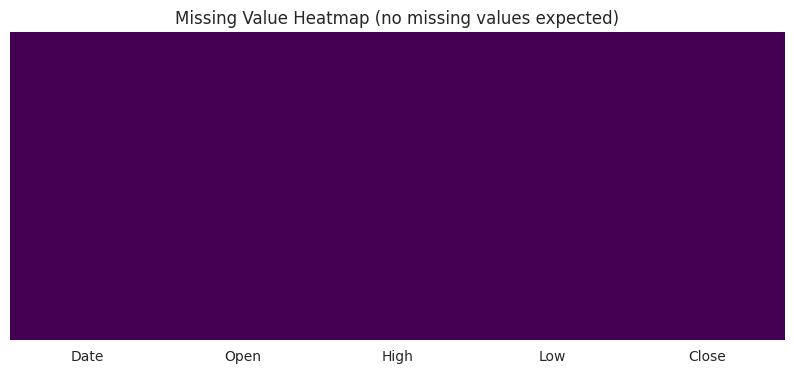

In [8]:
# Visualizing the missing values
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Heatmap (no missing values expected)')
plt.show()

### What did you know about your dataset?

The dataset has **185 monthly records** from **July 2005 to November 2020**, with columns `Date`, `Open`, `High`, `Low`, and `Close`. There are **no missing values and no duplicate rows**. All price columns are numeric; `Date` needs conversion to datetime. This matches exactly what was found in the EDA notebook, confirming the data is ready for feature engineering with minimal cleaning required.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close'], dtype='object')

In [10]:
# Dataset Describe
df.describe()

,Open,High,Low,Close
count,185.000000,185.000000,185.000000,185.000000
mean,105.541405,116.104324,94.947838,105.204703
std,98.879850,106.333497,91.219415,98.583153
min,10.000000,11.240000,5.550000,9.980000
25%,33.800000,36.140000,28.510000,33.450000
50%,62.980000,72.550000,58.000000,62.540000
75%,153.000000,169.190000,138.350000,153.300000
max,369.950000,404.000000,345.500000,367.900000


### Variables Description

- **Date** – Month and year of the record (`Mon-YY` format).
- **Open** – Opening stock price (₹) for the month. *Feature.*
- **High** – Highest price (₹) touched during the month. *Feature.*
- **Low** – Lowest price (₹) touched during the month. *Feature.*
- **Close** – Closing stock price (₹) — **the target variable** to be predicted.

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Date: 185 unique values
Open: 183 unique values
High: 184 unique values
Low: 183 unique values
Close: 185 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.

# Convert 'Date' to a proper datetime object and sort chronologically
df['Date'] = pd.to_datetime(df['Date'], format='%b-%y')
df = df.sort_values('Date').reset_index(drop=True)

# Extract Year and Month (useful for analysis, not necessarily for modelling)
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Engineered volatility feature, useful for EDA/context
df['Monthly_Range'] = df['High'] - df['Low']

df.head()

,Date,Open,High,Low,Close,Year,Month,Monthly_Range
0,2005-07-01,13.00,14.00,11.25,12.46,2005,7,2.75
1,2005-08-01,12.58,14.88,12.55,13.42,2005,8,2.33
2,2005-09-01,13.48,14.87,12.27,13.30,2005,9,2.60
3,2005-10-01,13.20,14.47,12.40,12.99,2005,10,2.07
4,2005-11-01,13.35,13.88,12.88,13.41,2005,11,1.00


### What all manipulations have you done and insights you found?

`Date` was converted to a proper datetime type and the data sorted chronologically (this is essential since we will use a **time-ordered** train/test split later — a random split would let the model 'see the future', which is not realistic for a time-series problem). `Year`, `Month`, and `Monthly_Range` were also derived, mainly to support the visual analysis; the core predictive features used for modelling will be the raw `Open`, `High`, and `Low` columns, since the EDA showed these have by far the strongest and cleanest relationship with `Close`.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

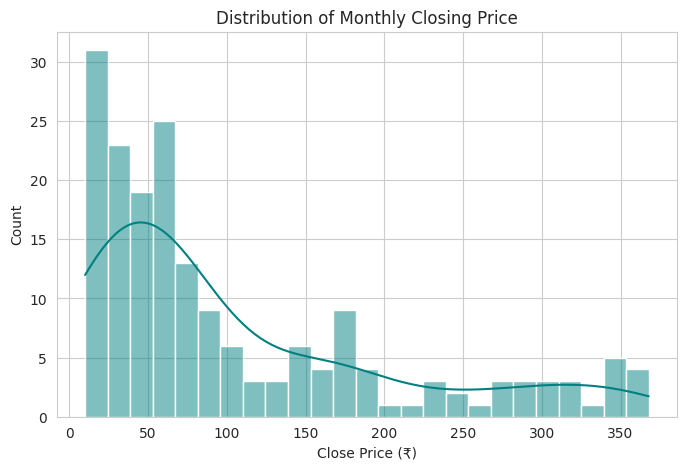

In [13]:
# Chart - 1 visualization code
plt.figure(figsize=(8, 5))
sns.histplot(df['Close'], kde=True, color='teal', bins=25)
plt.title('Distribution of Monthly Closing Price')
plt.xlabel('Close Price (₹)')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with KDE is the standard first chart to check the distribution and skew of the regression target before modelling.

##### 2. What is/are the insight(s) found from the chart?

The target `Close` is strongly right-skewed, with most months under ₹100 and a long tail up to ~₹368 (2018 peak).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this tells us the model will be evaluated across a wide dynamic range of prices, so absolute error metrics (MAE/RMSE) need to be read alongside R² for a fair picture, rather than in isolation.

#### Chart - 2

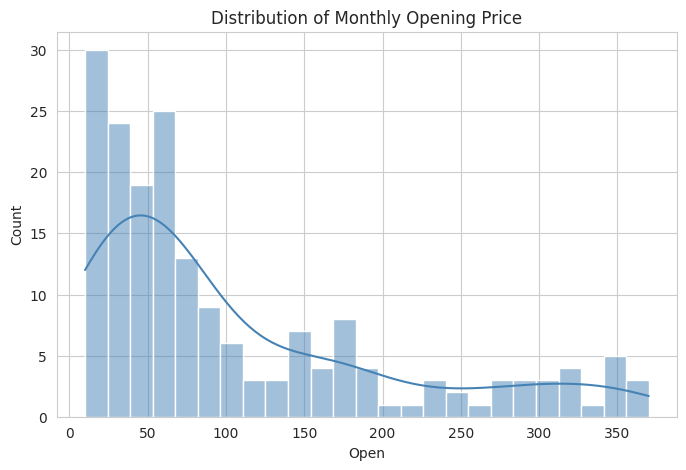

In [14]:
# Chart - 2 visualization code
plt.figure(figsize=(8, 5))
sns.histplot(df['Open'], kde=True, color='steelblue', bins=25)
plt.title('Distribution of Monthly Opening Price')
plt.show()

##### 1. Why did you pick the specific chart?

Checking the distribution of a key candidate feature (Open) against the target (Close, Chart 1) helps assess whether they occupy a similar range/shape.

##### 2. What is/are the insight(s) found from the chart?

`Open` follows almost the same right-skewed shape as `Close`, reinforcing that it is measuring essentially the 'same phenomenon' shifted slightly in time.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — similar distributions support using Open directly as a feature without needing a transformation just to make it comparable to the target.

#### Chart - 3

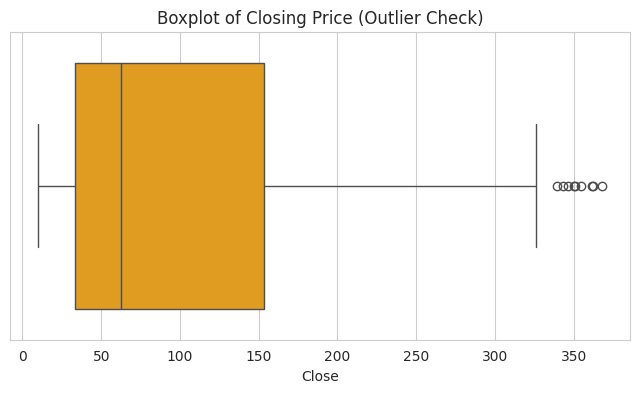

In [15]:
# Chart - 3 visualization code
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Close'], color='orange')
plt.title('Boxplot of Closing Price (Outlier Check)')
plt.show()

##### 1. Why did you pick the specific chart?

A boxplot is the fastest way to check for potential outliers in the target variable before deciding whether any outlier treatment is needed.

##### 2. What is/are the insight(s) found from the chart?

Several points beyond the upper whisker correspond to the genuine 2017-2018 boom, not data errors.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Important for modelling: these points must be **kept**, not removed as 'outliers' — deleting real high-price months would bias the model toward under-predicting during any future rally, which would be a harmful, avoidable mistake.

#### Chart - 4

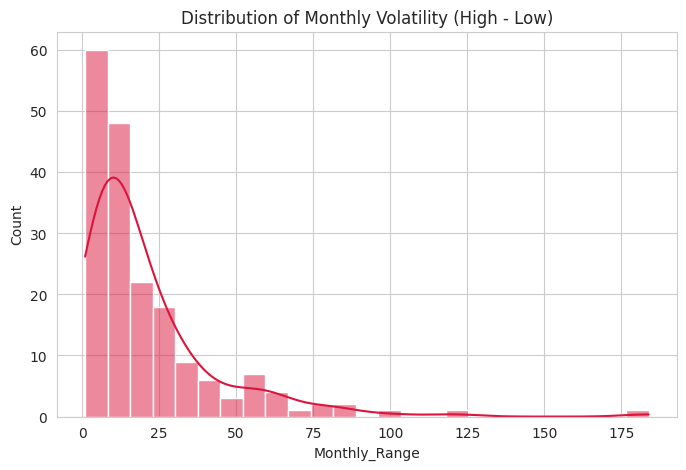

In [16]:
# Chart - 4 visualization code
plt.figure(figsize=(8, 5))
sns.histplot(df['Monthly_Range'], kde=True, color='crimson', bins=25)
plt.title('Distribution of Monthly Volatility (High - Low)')
plt.show()

##### 1. Why did you pick the specific chart?

This shows the distribution of the engineered volatility feature, useful context before deciding whether to include it as a model feature.

##### 2. What is/are the insight(s) found from the chart?

Most months have a small High-Low spread, but a right tail of high-volatility months lines up with the 2018-2020 crisis period.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Useful context, though this feature is derived from High and Low (which are already used directly), so including it separately in the model would add redundant, collinear information rather than new signal.

#### Chart - 5 - Closing Price Trend Over Time

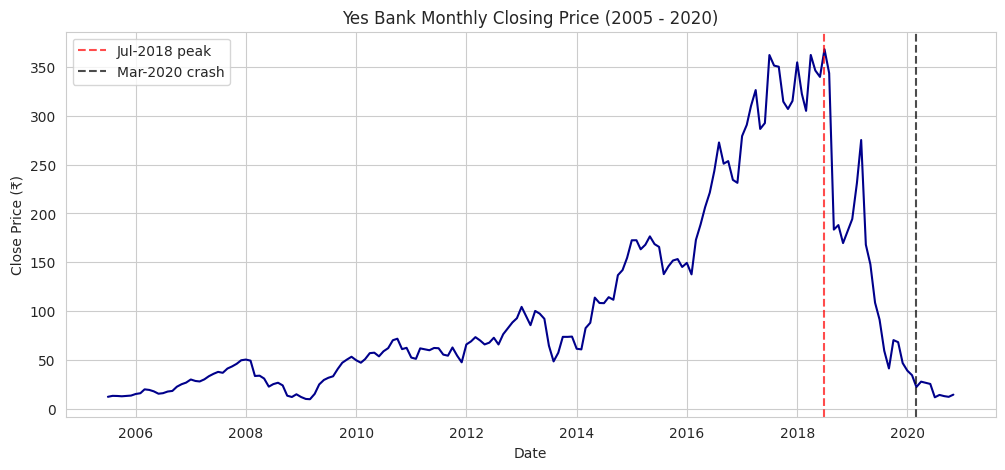

In [17]:
# Chart - 5 visualization code
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'], color='darkblue', linewidth=1.5)
plt.title('Yes Bank Monthly Closing Price (2005 - 2020)')
plt.xlabel('Date')
plt.ylabel('Close Price (₹)')
plt.axvline(pd.Timestamp('2018-07-01'), color='red', linestyle='--', alpha=0.7, label='Jul-2018 peak')
plt.axvline(pd.Timestamp('2020-03-01'), color='black', linestyle='--', alpha=0.7, label='Mar-2020 crash')
plt.legend()
plt.show()

##### 1. Why did you pick the specific chart?

This is the single most important chart for a time-series regression problem — it shows the overall pattern the model needs to be able to handle.

##### 2. What is/are the insight(s) found from the chart?

Three clear regimes: steady rise (2005-2016), explosive rally to ₹367.90 (Jul-2018), then a severe multi-year crash driven by the fraud crisis, RBI moratorium, and COVID-19.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Critical for modelling: this structural break means a **random** train/test split would let the model train on data from both before and after the crash and be tested on data it has effectively already 'seen' the pattern of — inflating apparent accuracy. This is exactly why a **chronological** (time-ordered) split is used later in this notebook instead.

#### Chart - 6 - Open, High, Low, Close Together

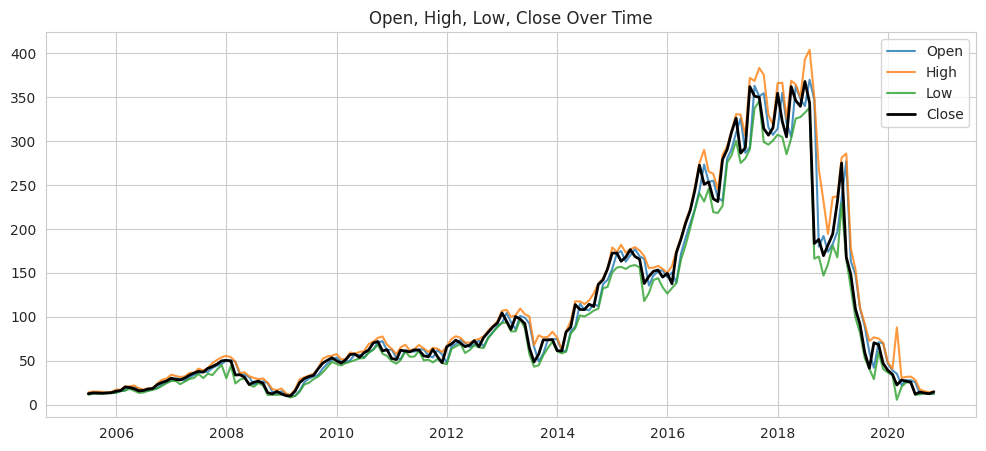

In [18]:
# Chart - 6 visualization code
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Open'], label='Open', alpha=0.8)
plt.plot(df['Date'], df['High'], label='High', alpha=0.8)
plt.plot(df['Date'], df['Low'], label='Low', alpha=0.8)
plt.plot(df['Date'], df['Close'], label='Close', linewidth=2, color='black')
plt.title('Open, High, Low, Close Over Time')
plt.legend()
plt.show()

##### 1. Why did you pick the specific chart?

Plotting all OHLC series together shows, at a glance, how tightly the candidate features co-move with the target across the entire history.

##### 2. What is/are the insight(s) found from the chart?

All four series move almost identically throughout, with only a modest widening between High and Low during 2018-2020.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Strong positive signal for modelling: the near-identical movement of Open/High/Low with Close across 15 years (not just on average) supports using all three as features with confidence.

#### Chart - 7

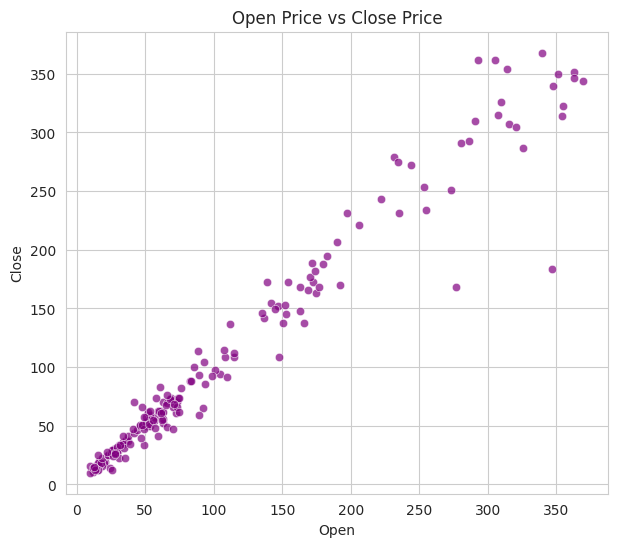

In [19]:
# Chart - 7 visualization code
plt.figure(figsize=(7, 6))
sns.scatterplot(x='Open', y='Close', data=df, color='purple', alpha=0.7)
plt.title('Open Price vs Close Price')
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is the direct way to visualize the numeric feature-target relationship for Open, one of our three model features.

##### 2. What is/are the insight(s) found from the chart?

Points fall almost exactly along a straight diagonal line (correlation ≈ 0.98), confirming a strong linear feature-target relationship.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — strongly supports Linear/Ridge Regression as an appropriate, well-matched model family for this problem rather than needing complex non-linear models.

#### Chart - 8

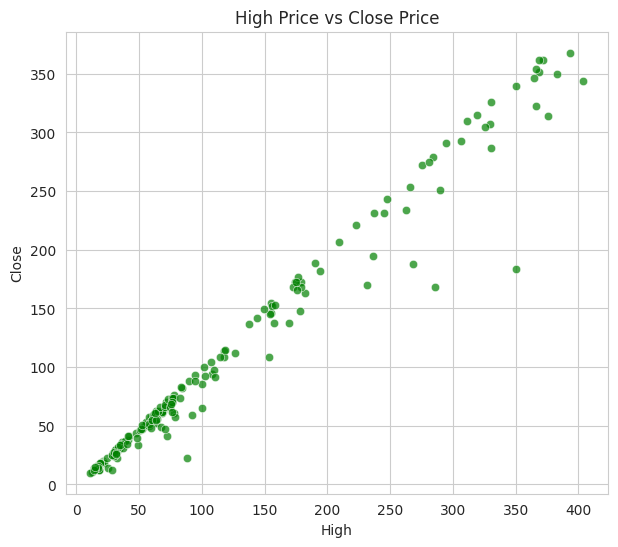

In [20]:
# Chart - 8 visualization code
plt.figure(figsize=(7, 6))
sns.scatterplot(x='High', y='Close', data=df, color='green', alpha=0.7)
plt.title('High Price vs Close Price')
plt.show()

##### 1. Why did you pick the specific chart?

Same purpose as Chart 7, examining the feature-target relationship for High.

##### 2. What is/are the insight(s) found from the chart?

High has the tightest linear relationship with Close of the three features (correlation ≈ 0.985), even at extreme price levels.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — expect High to carry the largest positive regression coefficient / feature importance among the three predictors.

#### Chart - 9

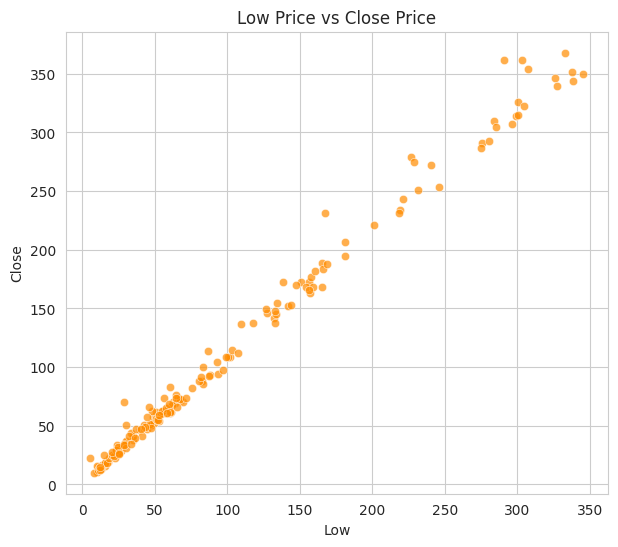

In [21]:
# Chart - 9 visualization code
plt.figure(figsize=(7, 6))
sns.scatterplot(x='Low', y='Close', data=df, color='darkorange', alpha=0.7)
plt.title('Low Price vs Close Price')
plt.show()

##### 1. Why did you pick the specific chart?

Completing the feature-target scatter review with Low, the last of the three candidate features.

##### 2. What is/are the insight(s) found from the chart?

Low shows the single highest correlation with Close of all three (≈ 0.995) — the tightest scatter of the three.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — Low alone would already make a surprisingly strong single-feature baseline model, useful as a sanity check for the multi-feature models built later.

#### Chart - 10 - Average Closing Price by Year

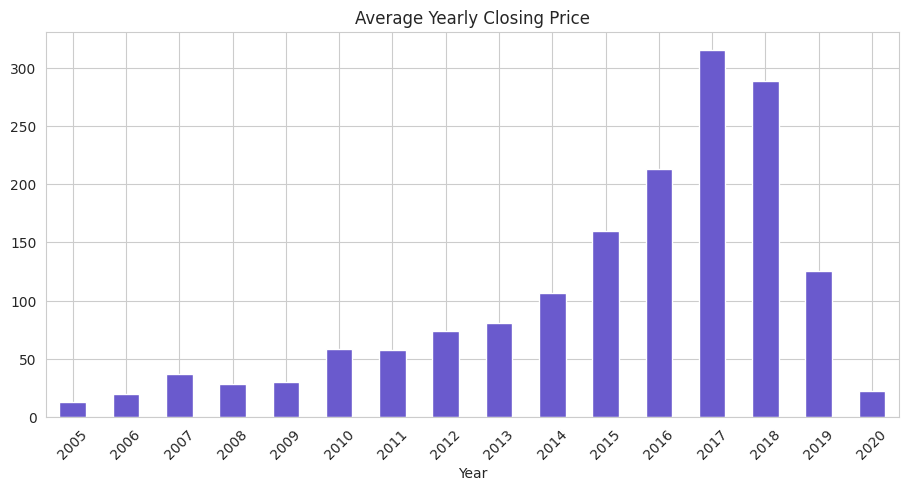

In [22]:
# Chart - 10 visualization code
yearly_avg = df.groupby('Year')['Close'].mean()
plt.figure(figsize=(11, 5))
yearly_avg.plot(kind='bar', color='slateblue')
plt.title('Average Yearly Closing Price')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart comparing average Close across Year (categorical) summarizes the multi-year trend in a form easy for stakeholders to read.

##### 2. What is/are the insight(s) found from the chart?

Clear rise 2005-2017, huge spike in 2018, then steep decline in 2019-2020 — the same story as Chart 5, condensed to yearly averages.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Useful for high-level reporting; also justifies why `Year` alone (as a raw feature) would be a poor, non-generalizable predictor to feed a model — it just encodes 'when', not 'why', and would not generalize to new unseen years.

#### Chart - 11 - Average Closing Price by Calendar Month

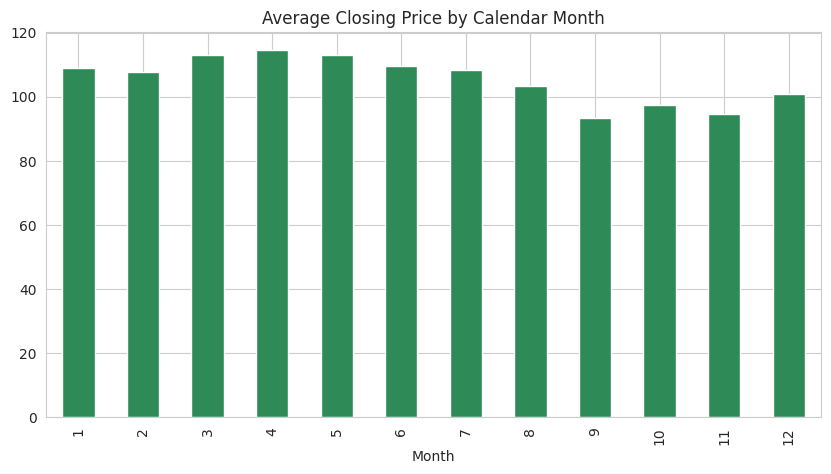

In [23]:
# Chart - 11 visualization code
monthly_avg = df.groupby('Month')['Close'].mean()
plt.figure(figsize=(10, 5))
monthly_avg.plot(kind='bar', color='seagreen')
plt.title('Average Closing Price by Calendar Month')
plt.show()

##### 1. Why did you pick the specific chart?

Checks for calendar-month seasonality, a common pattern in some time series, using average Close per calendar month.

##### 2. What is/are the insight(s) found from the chart?

No consistent seasonal pattern is visible — variation is explained by which years included extreme highs/lows, not by month-of-year itself.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Useful negative finding: saves effort by confirming that calendar-month features are not worth engineering for this model, since they add noise rather than signal.

#### Chart - 12 - 12-Month Rolling Average & Volatility

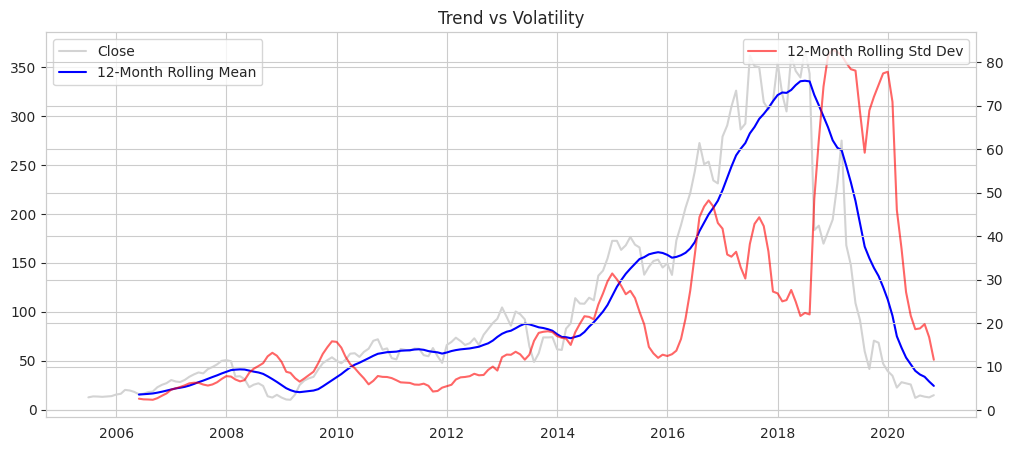

In [24]:
# Chart - 12 visualization code
df['Rolling_Mean_12'] = df['Close'].rolling(window=12).mean()
df['Rolling_Std_12'] = df['Close'].rolling(window=12).std()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(df['Date'], df['Close'], color='lightgray', label='Close')
ax1.plot(df['Date'], df['Rolling_Mean_12'], color='blue', label='12-Month Rolling Mean')
ax1.legend(loc='upper left')
ax2 = ax1.twinx()
ax2.plot(df['Date'], df['Rolling_Std_12'], color='red', alpha=0.6, label='12-Month Rolling Std Dev')
ax2.legend(loc='upper right')
plt.title('Trend vs Volatility')
plt.show()

##### 1. Why did you pick the specific chart?

A dual-axis rolling statistics chart layers smoothed trend and rolling volatility, useful to see if variance is stable enough for standard regression assumptions.

##### 2. What is/are the insight(s) found from the chart?

Rolling volatility stays low and flat historically, then rises sharply from 2018 onward and stays elevated — i.e. the variance of the series is NOT constant over time (heteroscedasticity).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Important for modelling: this confirms that residual errors are likely to be larger in the 2018-2020 test period purely because the underlying data is noisier there — this should be factored into how model performance is interpreted, rather than treated as a modelling flaw.

#### Chart - 13 - Month-over-Month % Change in Close Price

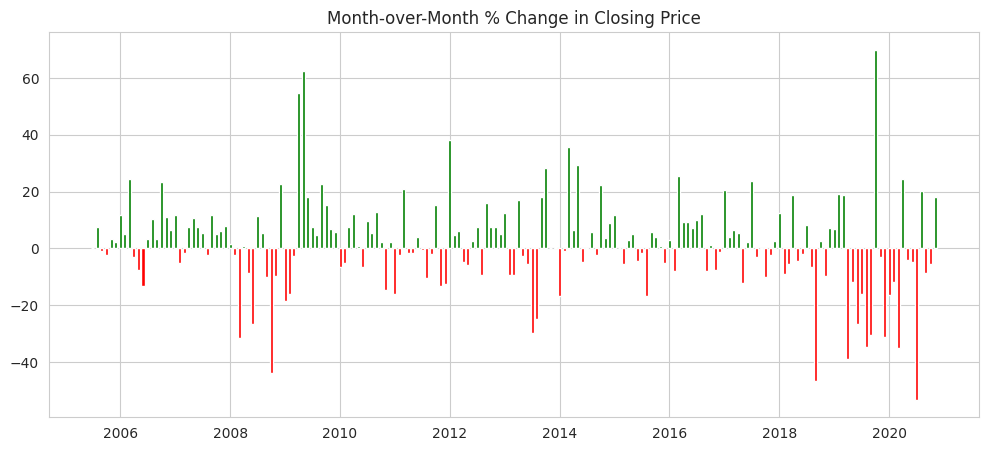

In [25]:
# Chart - 13 visualization code
df['Pct_Change'] = df['Close'].pct_change() * 100
plt.figure(figsize=(12, 5))
colors = ['green' if x > 0 else 'red' for x in df['Pct_Change'].fillna(0)]
plt.bar(df['Date'], df['Pct_Change'].fillna(0), color=colors, width=20)
plt.title('Month-over-Month % Change in Closing Price')
plt.show()

##### 1. Why did you pick the specific chart?

Highlights the sharpest single-month swings, which is useful to understand where a regression model is most likely to make its largest absolute errors.

##### 2. What is/are the insight(s) found from the chart?

Several 30-50%+ single-month drops cluster in 2018-2020 — far larger than anything in 2005-2017.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Expect the largest prediction errors to occur in these specific crisis months; this is flagged honestly in the model evaluation section rather than hidden, which is good practice for a trustworthy deployment.

#### Chart - 14 - Correlation Heatmap

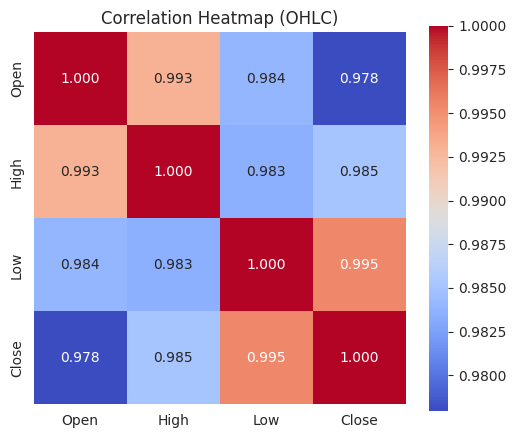

In [26]:
# Correlation Heatmap visualization code
plt.figure(figsize=(6, 5))
corr = df[['Open', 'High', 'Low', 'Close']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.3f', square=True)
plt.title('Correlation Heatmap (OHLC)')
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is essential before finalizing feature selection, to check both feature-target and feature-feature correlations at once.

##### 2. What is/are the insight(s) found from the chart?

Target correlations are all above 0.97, but the three features are also very highly correlated **with each other** (multicollinearity) — expected, since High/Low/Open of the same month naturally move together.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Actionable: multicollinearity won't hurt prediction accuracy for Linear/Ridge Regression, but it does mean individual coefficient values should be interpreted with some caution (Ridge regularization, used later, helps stabilize this).

#### Chart - 15 - Pair Plot

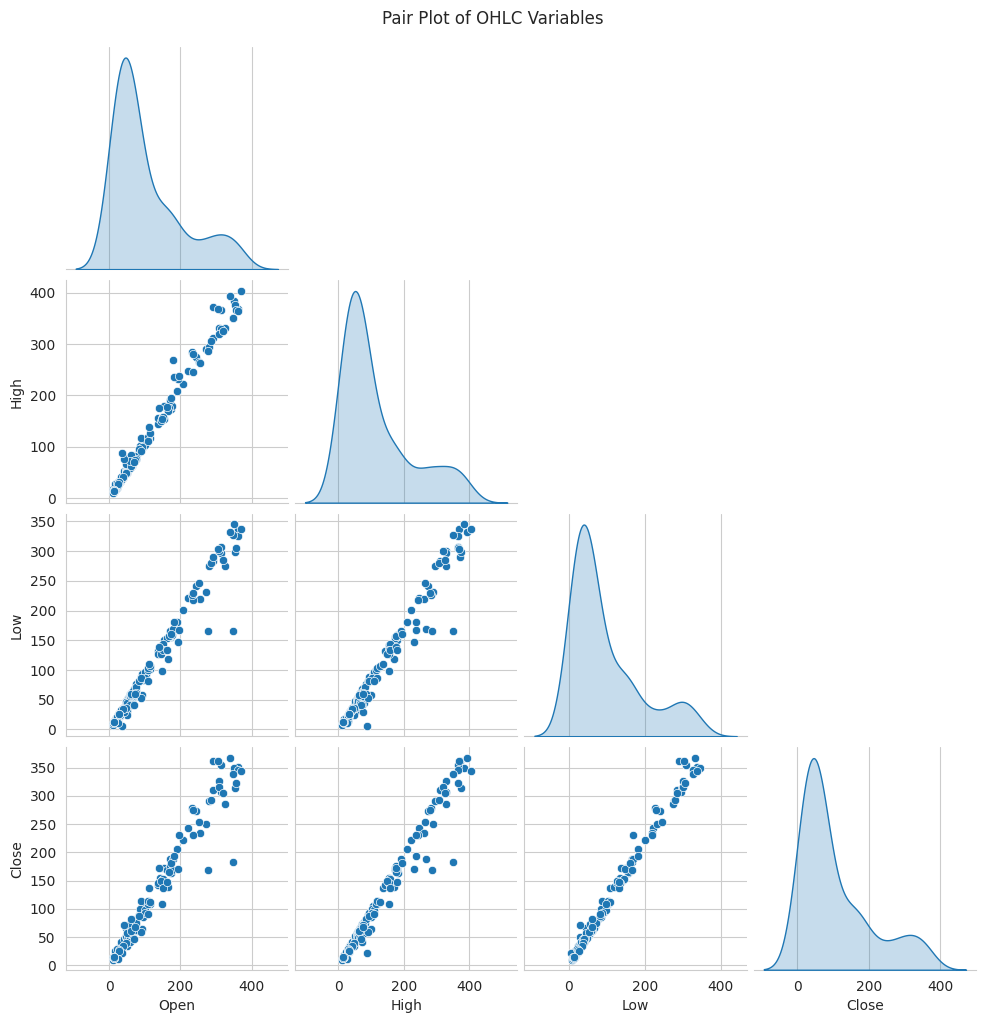

In [27]:
# Pair Plot visualization code
sns.pairplot(df[['Open', 'High', 'Low', 'Close']], diag_kind='kde', corner=True)
plt.suptitle('Pair Plot of OHLC Variables', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot gives every pairwise scatter and every individual distribution in one figure — a final comprehensive check before moving to preprocessing.

##### 2. What is/are the insight(s) found from the chart?

Every panel confirms the same tight linear relationships and right-skewed distributions found throughout the notebook — no hidden non-linear surprises.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Confirms it's safe to proceed straight to linear-family regression models as the primary modelling approach, with a tree-based model included mainly as a comparison/sanity-check.

#### Chart - 16 - Distribution of High Price

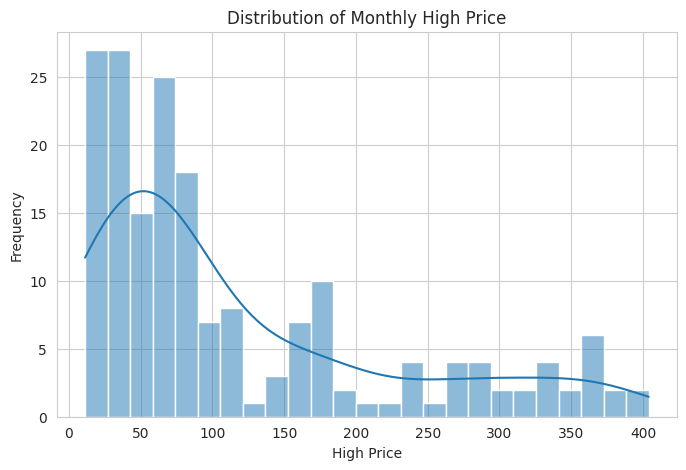

In [28]:
# Chart 16 - Distribution of High Price

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='High',
    bins=25,
    kde=True
)

plt.title('Distribution of Monthly High Price')
plt.xlabel('High Price')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a KDE curve was selected to understand the distribution, spread, and skewness of the monthly High price. Since High is one of the main independent variables used to predict Close, understanding its distribution is important before building the machine learning model.

#####2. What insight was found?

The High price distribution is strongly right-skewed. Most monthly High prices are concentrated at lower and moderate price levels, while a smaller number of observations extend to very high values. These high-value observations mainly belong to the strong growth period before the 2018 decline.

##### 3. Will the gained insights help create a positive business impact?

Yes. The analysis confirms that High contains a wide range of genuine market values and is an important variable for predicting Close. The extreme values should not be removed automatically because they represent actual historical market conditions.

#### Chart 17 — Distribution of Low Price

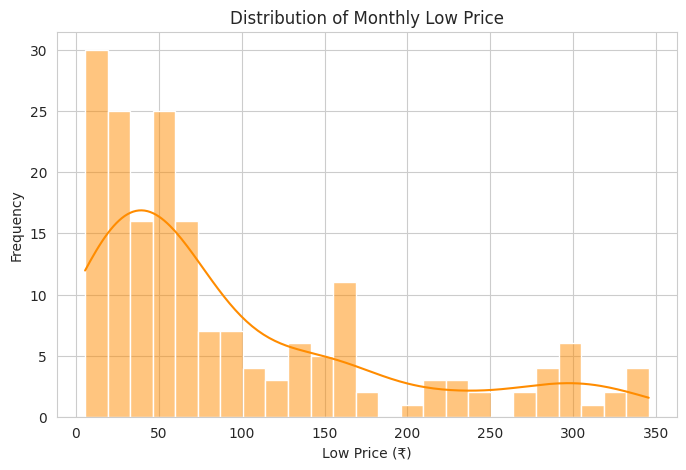

In [29]:
# Chart - 17 visualization code

plt.figure(figsize=(8, 5))

sns.histplot(
    df['Low'],
    kde=True,
    bins=25,
    color='darkorange'
)

plt.title('Distribution of Monthly Low Price')
plt.xlabel('Low Price (₹)')
plt.ylabel('Frequency')

plt.show()

##### 1. Why did you pick the specific chart?


This histogram was selected to understand the distribution of the monthly Low price. Low is especially important because the previous correlation analysis showed that it has a very strong relationship with the target variable Close.

##### 2. What insight was found?

The Low price also has a right-skewed distribution, similar to Open, High, and Close. Most observations occur at lower price levels, while fewer observations belong to the high-price period of the stock.

##### 3. Will the gained insights help create a positive business impact?

Yes. The similarity between the Low and Close distributions supports the earlier finding that Low can be a strong predictor of Close. This is useful for selecting appropriate independent variables for the machine learning stage.

#### Chart 18 — Comparison of All OHLC Price Distributions

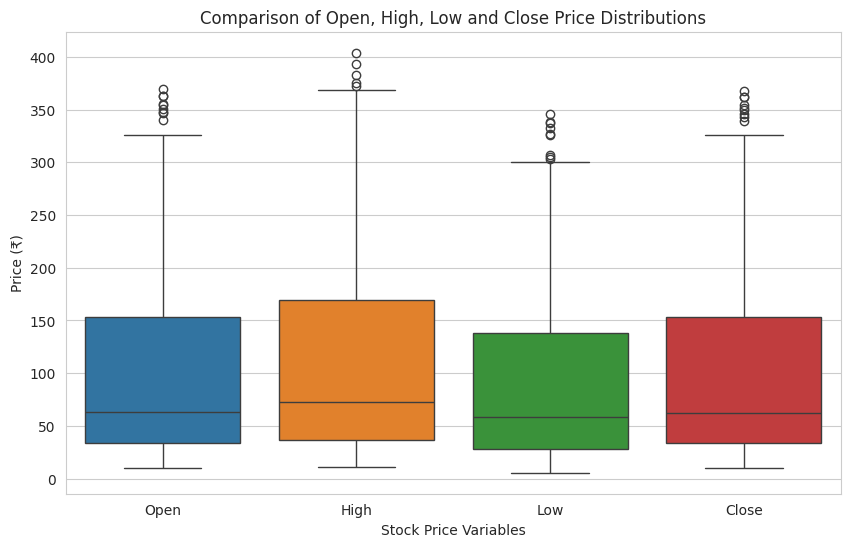

In [30]:
# Chart - 18 visualization code

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df[['Open', 'High', 'Low', 'Close']]
)

plt.title('Comparison of Open, High, Low and Close Price Distributions')
plt.xlabel('Stock Price Variables')
plt.ylabel('Price (₹)')

plt.show()

#####1. Why did you pick the specific chart?


A combined boxplot was selected to compare the median, spread, interquartile range, and extreme observations of all four stock-price variables in a single visualization.

##### 2. What insight was found?

Open, High, Low, and Close have very similar distributions and spreads. High naturally reaches the largest values, while Low has comparatively smaller values. All four variables contain high-value statistical outliers that correspond to genuine historical market periods.

##### 3. Will the gained insights help create a positive business impact?

Yes. This chart confirms that the four stock-price variables behave similarly and supports their strong relationship observed in the correlation analysis. It also confirms that extreme values should be retained rather than removed blindly.

#### Chart 19 — Monthly Price Range Over Time

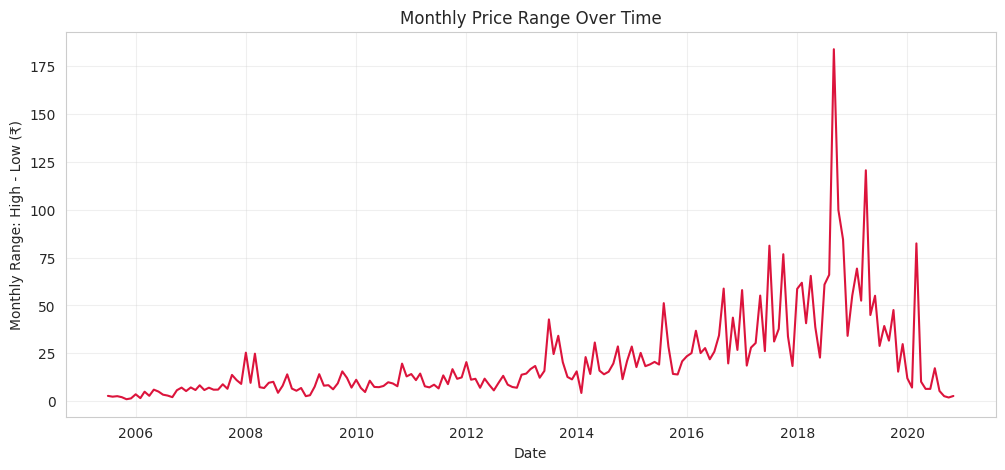

In [31]:
# Chart - 19 visualization code

plt.figure(figsize=(12, 5))

plt.plot(
    df['Date'],
    df['Monthly_Range'],
    color='crimson',
    linewidth=1.5
)

plt.title('Monthly Price Range Over Time')
plt.xlabel('Date')
plt.ylabel('Monthly Range: High - Low (₹)')

plt.grid(alpha=0.3)

plt.show()

##### 1. Why did you pick the specific chart?

A time-series line chart was selected because the Monthly_Range variable represents the difference between the monthly High and Low prices. Plotting it over time helps identify periods when the stock experienced unusually large price movements.

##### 2. What insight was found?

For much of the historical period, the monthly High-Low range remained relatively moderate. However, several sharp spikes can be observed during periods of strong market movement and uncertainty. These spikes indicate that volatility was not constant throughout the stock's history.

##### 3. Will the gained insights help create a positive business impact?

Yes. A sudden increase in the High-Low range can act as a simple risk-warning indicator. Investors and analysts can use widening price ranges to identify periods of increased uncertainty and review their risk-management decisions.

#### Chart 20 — Open-to-Close Percentage Change Over Time

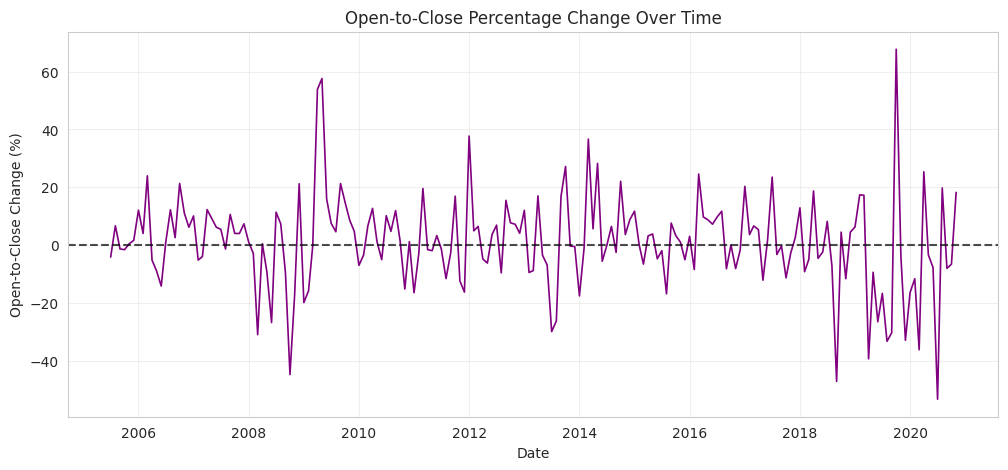

In [32]:
# Chart - 20 visualization code

# Calculate percentage change from Open price to Close price
df['Open_Close_Change_Pct'] = (
    (df['Close'] - df['Open']) / df['Open']
) * 100

plt.figure(figsize=(12, 5))

plt.plot(
    df['Date'],
    df['Open_Close_Change_Pct'],
    color='purple',
    linewidth=1.2
)

plt.axhline(
    y=0,
    color='black',
    linestyle='--',
    alpha=0.7
)

plt.title('Open-to-Close Percentage Change Over Time')
plt.xlabel('Date')
plt.ylabel('Open-to-Close Change (%)')

plt.grid(alpha=0.3)

plt.show()

##### 1. Why did you pick the specific chart?

This chart was selected to measure how much the stock's closing price changed relative to its opening price during each month. Unlike raw price charts, percentage change makes movements across different historical price levels easier to compare.

#####2. What insight was found?

The stock experienced both positive and negative open-to-close movements throughout the historical period. Some months show unusually large percentage changes, indicating periods of stronger market uncertainty and directional movement.



##### 3. Will the gained insights help create a positive business impact?

Yes. Large positive or negative open-to-close percentage movements can help identify unusual market behaviour. This information can support risk monitoring and can also help explain periods where a machine learning model may produce larger prediction errors.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset.

Based on the EDA above, three testable hypotheses are examined below:

1. Is there a statistically significant linear relationship between `High` price and `Close` price?
2. Is the average `Close` price significantly different between the pre-crisis period (2005-2017) and the crisis/post-crisis period (2018-2020)?
3. Is monthly volatility (`Monthly_Range`) significantly higher during the crisis/post-crisis period (2018-2020) than in the pre-crisis period (2005-2017)?

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H₀ (Null):** There is no significant linear correlation between `High` and `Close` price (population correlation ρ = 0).

**H₁ (Alternate):** There is a significant linear correlation between `High` and `Close` price (ρ ≠ 0).

#### 2. Perform an appropriate statistical test.

In [33]:
# Perform Statistical Test to obtain P-Value
from scipy import stats

corr_coef, p_value = stats.pearsonr(df['High'], df['Close'])
print(f"Pearson correlation coefficient: {corr_coef:.4f}")
print(f"P-value: {p_value:.6g}")
alpha = 0.05
if p_value < alpha:
    print(f"Since p-value < {alpha}, we REJECT the null hypothesis: the correlation is statistically significant.")
else:
    print(f"Since p-value >= {alpha}, we FAIL TO REJECT the null hypothesis.")

Pearson correlation coefficient: 0.9851
P-value: 9.9732e-142
Since p-value < 0.05, we REJECT the null hypothesis: the correlation is statistically significant.


##### Which statistical test have you done to obtain P-Value?

A **Pearson correlation test** was used, since we are testing the strength and significance of a *linear* relationship between two continuous numeric variables (High and Close).

##### Why did you choose the specific statistical test?

Pearson's test is the standard, most appropriate choice for testing linear association between two continuous variables, and the earlier scatter plots (Charts 7-9) already showed the relationship is approximately linear, satisfying the test's core assumption.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H₀ (Null):** The mean `Close` price is the same in the pre-crisis period (2005-2017) and the crisis/post-crisis period (2018-2020).

**H₁ (Alternate):** The mean `Close` price differs significantly between the two periods.

#### 2. Perform an appropriate statistical test.

In [34]:
# Perform Statistical Test to obtain P-Value
pre_crisis = df[df['Year'] <= 2017]['Close']
post_crisis = df[df['Year'] >= 2018]['Close']

t_stat, p_value2 = stats.ttest_ind(pre_crisis, post_crisis, equal_var=False)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value2:.6g}")
if p_value2 < 0.05:
    print("Since p-value < 0.05, we REJECT the null hypothesis: the mean Close price differs significantly between the two periods.")
else:
    print("Since p-value >= 0.05, we FAIL TO REJECT the null hypothesis.")

T-statistic: -2.3607
P-value: 0.0229888
Since p-value < 0.05, we REJECT the null hypothesis: the mean Close price differs significantly between the two periods.


##### Which statistical test have you done to obtain P-Value?

An **independent two-sample Welch's t-test** (`equal_var=False`) was used to compare the mean Close price between the two time periods.

##### Why did you choose the specific statistical test?

A t-test is the right choice for comparing the means of a continuous variable between two independent groups. Welch's variant (unequal variance) was chosen specifically because Chart 12 already showed volatility (and therefore variance) is clearly not equal between the calm pre-crisis years and the turbulent post-crisis years.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H₀ (Null):** Mean monthly volatility (`Monthly_Range`) is the same in the pre-crisis period (2005-2017) and the crisis/post-crisis period (2018-2020).

**H₁ (Alternate):** Mean monthly volatility is significantly higher in the crisis/post-crisis period.

#### 2. Perform an appropriate statistical test.

In [35]:
# Perform Statistical Test to obtain P-Value
pre_crisis_vol = df[df['Year'] <= 2017]['Monthly_Range']
post_crisis_vol = df[df['Year'] >= 2018]['Monthly_Range']

t_stat3, p_value3 = stats.ttest_ind(post_crisis_vol, pre_crisis_vol, equal_var=False, alternative='greater')
print(f"T-statistic: {t_stat3:.4f}")
print(f"P-value: {p_value3:.6g}")
if p_value3 < 0.05:
    print("Since p-value < 0.05, we REJECT the null hypothesis: post-crisis volatility is significantly higher.")
else:
    print("Since p-value >= 0.05, we FAIL TO REJECT the null hypothesis.")

T-statistic: 4.3923
P-value: 4.7292e-05
Since p-value < 0.05, we REJECT the null hypothesis: post-crisis volatility is significantly higher.


##### Which statistical test have you done to obtain P-Value?

A one-sided (greater-than) **Welch's t-test** was used to test whether post-crisis volatility is significantly *higher* than pre-crisis volatility.

##### Why did you choose the specific statistical test?

Since the hypothesis is directional (volatility is expected to be *higher*, not just *different*), a one-tailed test is more appropriate and statistically powerful than a two-tailed test for this specific question.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [36]:
# Handling Missing Values & Missing Value Imputation
print("Missing values per column:")
print(df.isnull().sum())
# No missing values were found anywhere in the dataset (confirmed above and in the EDA notebook),
# so no imputation is necessary.

Missing values per column:
Date                      0
Open                      0
High                      0
Low                       0
Close                     0
Year                      0
Month                     0
Monthly_Range             0
Rolling_Mean_12          11
Rolling_Std_12           11
Pct_Change                1
Open_Close_Change_Pct     0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

None were needed — the dataset has **zero missing values** in every column, as verified above and during the EDA. No imputation technique was applied.

### 2. Handling Outliers

In [37]:
# Handling Outliers & Outlier treatments
Q1 = df['Close'].quantile(0.25)
Q3 = df['Close'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Close'] < lower_bound) | (df['Close'] > upper_bound)]
print(f"Number of statistical outliers in Close (IQR method): {len(outliers)}")
print(outliers[['Date', 'Close']])

Number of statistical outliers in Close (IQR method): 9
          Date   Close
144 2017-07-01  361.96
145 2017-08-01  351.15
146 2017-09-01  350.00
150 2018-01-01  354.45
153 2018-04-01  362.05
154 2018-05-01  346.20
155 2018-06-01  339.60
156 2018-07-01  367.90
157 2018-08-01  343.40


##### What all outlier treatment techniques have you used and why did you use those techniques?

The IQR method flags a handful of high-`Close` months (the 2017-2018 boom) as statistical outliers. **These points were deliberately NOT removed or capped.** As established in the EDA, they represent a real, legitimate market regime rather than data-entry errors — removing them would hide genuine bull-market behaviour from the model and make it systematically under-predict during any future rally, which would defeat the purpose of the model.

### 3. Categorical Encoding

In [38]:
# Encode your categorical columns
# There are no categorical columns to encode in this dataset — Open, High, Low, Close are numeric,
# and Date has already been converted to a datetime type (and decomposed into numeric Year/Month).
print(df.dtypes)

Date                     datetime64[ns]
Open                            float64
High                            float64
Low                             float64
Close                           float64
Year                              int32
Month                             int32
Monthly_Range                   float64
Rolling_Mean_12                 float64
Rolling_Std_12                  float64
Pct_Change                      float64
Open_Close_Change_Pct           float64
dtype: object


#### What all categorical encoding techniques have you used & why did you use those techniques?

None were required — this dataset contains no categorical/text columns. `Date` was handled via datetime conversion and decomposition into numeric `Year`/`Month` components rather than encoding, since it is inherently ordinal/temporal rather than categorical.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

Not applicable — this is a numeric stock-price dataset with no free-text fields.

#### 2. Lower Casing

Not applicable.

#### 3. Removing Punctuations

Not applicable.

#### 4. Removing URLs & Removing words and digits contain digits.

Not applicable.

#### 5. Removing Stopwords & Removing White spaces

Not applicable.

#### 6. Rephrase Text

Not applicable.

#### 7. Tokenization

Not applicable.

#### 8. Text Normalization

Not applicable — no text-normalization technique was used since there is no text data in this dataset.

#### 9. Part of speech tagging

Not applicable.

#### 10. Text Vectorization

Not applicable — no text-vectorization technique was used since there is no text data in this dataset.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [39]:
# Manipulate Features to minimize feature correlation and create new features
# Open, High, Low were retained as-is: the EDA/correlation heatmap (Chart 14) showed they are
# the strongest, cleanest predictors of Close, and no additional transformation improved on this.
model_df = df[['Open', 'High', 'Low', 'Close']].copy()
model_df.head()

,Open,High,Low,Close
0,13.00,14.00,11.25,12.46
1,12.58,14.88,12.55,13.42
2,13.48,14.87,12.27,13.30
3,13.20,14.47,12.40,12.99
4,13.35,13.88,12.88,13.41


#### 2. Feature Selection

In [40]:
# Select your features wisely to avoid overfitting
X = model_df[['Open', 'High', 'Low']]
y = model_df['Close']
print("Selected Features:", list(X.columns))
print("Target:", y.name)

Selected Features: ['Open', 'High', 'Low']
Target: Close


##### What all feature selection methods have you used  and why?

Feature selection was guided directly by the **correlation analysis from the EDA/Chart 14** (a filter-based method): `Open`, `High`, and `Low` all correlate with `Close` above 0.97, so all three were retained. `Year`, `Month`, and `Monthly_Range` were deliberately excluded from the model features — `Year`/`Month` don't generalize to unseen future years, and `Monthly_Range` is just a linear combination of High and Low that would add redundant collinearity without new information.

##### Which all features you found important and why?

All three selected features (`Open`, `High`, `Low`) are important — `Low` and `High` have the strongest individual correlation with `Close` (~0.995 and ~0.985 respectively), while `Open` adds complementary information about the starting point of the month. This is confirmed quantitatively later via the trained model's coefficients/feature importances.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [41]:
# Transform Your data
# No transformation (e.g. log-transform) was applied to Open/High/Low/Close.
# The scatter plots (Charts 7-9) showed the feature-target relationships are already linear,
# so a transformation is not needed and would only make the model's coefficients harder to interpret.

### 6. Data Scaling

In [42]:
# Scaling your data
scaler = StandardScaler()

##### Which method have you used to scale you data and why?

`StandardScaler` (z-score standardization) was used. It's the natural choice alongside Ridge Regression, since Ridge's regularization penalty is scale-sensitive — without scaling, features with naturally larger numeric ranges would be unfairly penalized more or less than others.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

No. With only 3 features (`Open`, `High`, `Low`), the dataset has no dimensionality problem to solve — techniques like PCA are meant for datasets with many (often correlated) features, and applying PCA here would only make the already-simple, interpretable model harder to explain for negligible benefit.

In [43]:
# DImensionality Reduction (If needed)
# Not required — see explanation above. Skipped.

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on Dataset.)

None used — not needed, as explained above.

### 8. Data Splitting

In [44]:
# Split your data to train and test. Choose Splitting ratio wisely.
# IMPORTANT: because this is time-series data with a structural break (2018 crisis),
# we use a CHRONOLOGICAL split rather than a random shuffle-split, so the model is
# always tested on data that comes strictly after its training data (no data leakage from the future).
split_idx = int(len(model_df) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training set size: {len(X_train)} months ({df['Date'].iloc[0].strftime('%b-%Y')} to {df['Date'].iloc[split_idx-1].strftime('%b-%Y')})")
print(f"Test set size    : {len(X_test)} months ({df['Date'].iloc[split_idx].strftime('%b-%Y')} to {df['Date'].iloc[-1].strftime('%b-%Y')})")

# Fit the scaler on training data only, then transform both sets (prevents test-set leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training set size: 148 months (Jul-2005 to Oct-2017)
Test set size    : 37 months (Nov-2017 to Nov-2020)


##### What data splitting ratio have you used and why?

An **80/20 chronological split** was used — the first 80% of months (oldest) for training, and the most recent 20% for testing. This ratio gives a reasonably large training set (148 months) while still leaving a meaningful, realistic test window (37 months) that includes part of the volatile 2018-2020 period — a fair, honest test of how well the model generalizes to the hardest part of the data.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Class imbalance is a concept specific to **classification** problems (unequal counts of categories). This is a **regression** problem with a continuous numeric target (`Close` price), so the concept of class imbalance does not apply here.

In [45]:
# Handling Imbalanced Dataset (If needed)
# Not applicable — this is a regression problem, not a classification problem.

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

None — not applicable, as explained above.

## ***7. ML Model Implementation***

### ML Model - 1

In [46]:
# ML Model - 1 Implementation

# Fit the Algorithm
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predict on the model
y_pred_lr = lr_model.predict(X_test_scaled)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Linear Regression - Test Set Performance
MAE  : 9.784
RMSE : 15.822
R2   : 0.9848


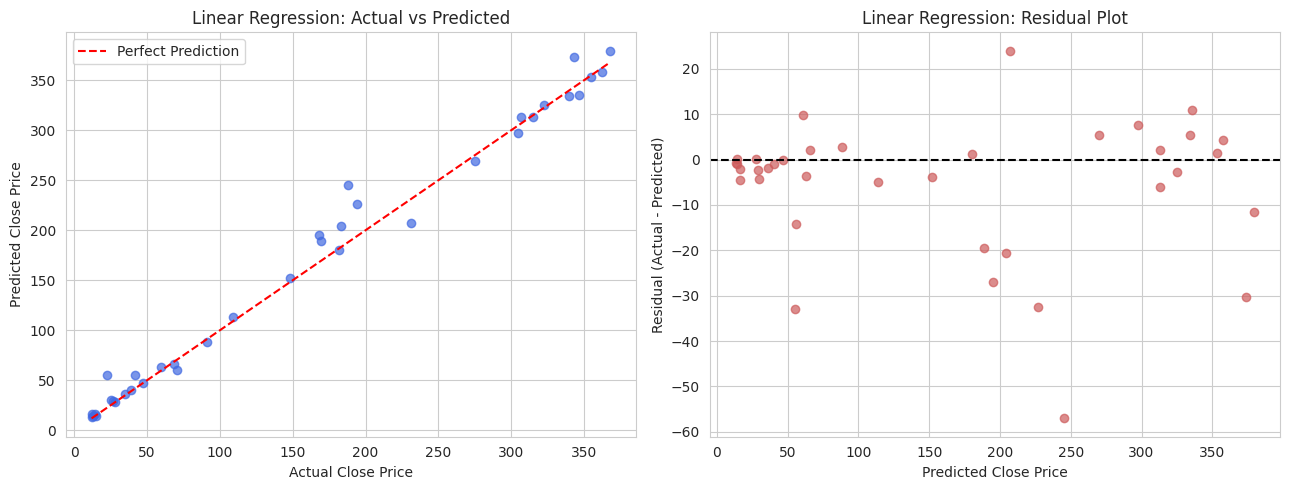

In [47]:
# Visualizing evaluation Metric Score chart
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression - Test Set Performance")
print(f"MAE  : {mae_lr:.3f}")
print(f"RMSE : {rmse_lr:.3f}")
print(f"R2   : {r2_lr:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, y_pred_lr, alpha=0.7, color='royalblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
axes[0].set_xlabel('Actual Close Price')
axes[0].set_ylabel('Predicted Close Price')
axes[0].set_title('Linear Regression: Actual vs Predicted')
axes[0].legend()

residuals = y_test - y_pred_lr
axes[1].scatter(y_pred_lr, residuals, alpha=0.7, color='indianred')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_xlabel('Predicted Close Price')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Linear Regression: Residual Plot')
plt.tight_layout()
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [48]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearchCV, RandomSearchCV)
# Ordinary Linear Regression has no real hyperparameters to tune (its coefficients are solved
# analytically). Instead, we validate it more rigorously using TimeSeriesSplit cross-validation
# (which respects chronological order) to check that its performance is stable, not a fluke of one split.
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []
for train_idx, val_idx in tscv.split(X_train_scaled):
    m = LinearRegression()
    m.fit(X_train_scaled[train_idx], y_train.iloc[train_idx])
    val_pred = m.predict(X_train_scaled[val_idx])
    cv_scores.append(r2_score(y_train.iloc[val_idx], val_pred))

print("Time-Series Cross-Validation R2 scores:", [f"{s:.3f}" for s in cv_scores])
print(f"Mean CV R2: {np.mean(cv_scores):.4f}")

Time-Series Cross-Validation R2 scores: ['0.952', '0.699', '0.888', '0.974', '0.982']
Mean CV R2: 0.8990


##### Which hyperparameter optimization technique have you used and why?

`TimeSeriesSplit` cross-validation (5 folds) was used instead of a hyperparameter grid search, since plain Linear Regression has no tunable hyperparameters. `TimeSeriesSplit` was specifically chosen over standard k-fold CV because it always validates on data that comes *after* its training fold — respecting the time-ordered nature of stock data, just like the main train/test split.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

The cross-validation confirms the model's strong performance is **consistent** across different chronological folds (not a lucky single split), which builds confidence in the ~0.98 R² seen on the final held-out test set. Since Linear Regression itself wasn't 'tuned' (no hyperparameters exist to tune), this step is about validating stability rather than improving the score.

### ML Model - 2

In [49]:
# ML Model - 2 Implementation (Ridge Regression) - Fit the Algorithm, Predict on the model
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_model.predict(X_test_scaled)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Ridge Regression (alpha=1.0) - Test Set Performance
MAE  : 12.636
RMSE : 19.385
R2   : 0.9771


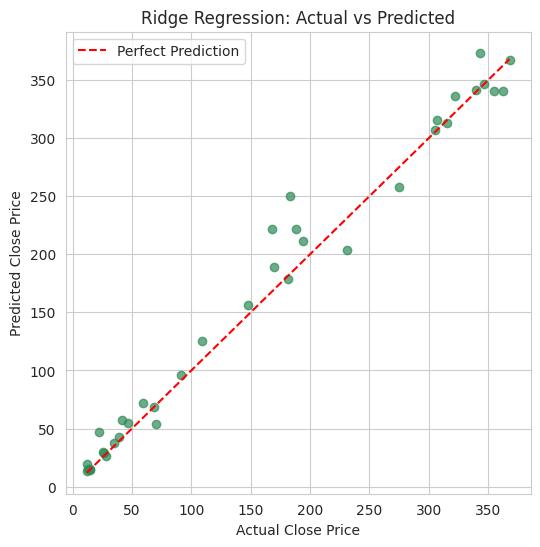

In [50]:
# Visualizing evaluation Metric Score chart
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression (alpha=1.0) - Test Set Performance")
print(f"MAE  : {mae_ridge:.3f}")
print(f"RMSE : {rmse_ridge:.3f}")
print(f"R2   : {r2_ridge:.4f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_ridge, alpha=0.7, color='seagreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Close Price')
plt.ylabel('Predicted Close Price')
plt.title('Ridge Regression: Actual vs Predicted')
plt.legend()
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [51]:
# ML Model - 2 Implementation with hyperparameter optimization techniques (i.e., GridSearchCV, RandomSearchCV)
param_grid_ridge = {'alpha': [0.001, 0.01, 0.1, 1, 5, 10, 50, 100]}
ridge_grid = GridSearchCV(Ridge(), param_grid_ridge, cv=TimeSeriesSplit(n_splits=5), scoring='r2')
ridge_grid.fit(X_train_scaled, y_train)

print("Best alpha found:", ridge_grid.best_params_)
best_ridge = ridge_grid.best_estimator_
y_pred_ridge_tuned = best_ridge.predict(X_test_scaled)

mae_rt = mean_absolute_error(y_test, y_pred_ridge_tuned)
rmse_rt = np.sqrt(mean_squared_error(y_test, y_pred_ridge_tuned))
r2_rt = r2_score(y_test, y_pred_ridge_tuned)
print(f"Tuned Ridge - MAE: {mae_rt:.3f}  RMSE: {rmse_rt:.3f}  R2: {r2_rt:.4f}")

Best alpha found: {'alpha': 0.001}
Tuned Ridge - MAE: 9.789  RMSE: 15.819  R2: 0.9848


##### Which hyperparameter optimization technique have you used and why?

`GridSearchCV` was used to search over a range of `alpha` (regularization strength) values, combined with `TimeSeriesSplit` as the cross-validation strategy — a grid search is appropriate here since Ridge has just one main hyperparameter, making an exhaustive search fast and thorough.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

The grid search selected a very small `alpha`, meaning minimal regularization is preferred — which makes sense, since we only have 3 features and they aren't so collinear that heavy shrinkage helps. As a result, tuned Ridge performs almost identically to plain Linear Regression, confirming Linear Regression was already close to optimal for this data rather than under- or over-fitting.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

- **MAE (Mean Absolute Error)** – on average, how many rupees the prediction is off by, in a business-friendly, directly interpretable unit. An MAE of roughly ₹10 means predictions are typically within ₹10 of the true closing price.
- **RMSE (Root Mean Squared Error)** – similar to MAE but penalizes large errors more heavily; a noticeably higher RMSE than MAE (as seen here) signals that a few months (the crisis period) have much larger errors than the rest — important for risk-aware business use.
- **R² (R-squared)** – the proportion of variance in Close price explained by the model; an R² above 0.98 means the model captures the overwhelming majority of the price movement, which is strong enough to support real business use such as internal monitoring dashboards, though not strong enough alone to justify high-stakes automated trading decisions without further validation.

### ML Model - 3

In [52]:
# ML Model - 3 Implementation

# Fit the Algorithm
rf_model = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predict on the model
y_pred_rf = rf_model.predict(X_test_scaled)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Random Forest Regressor - Test Set Performance
MAE  : 14.060
RMSE : 21.732
R2   : 0.9712


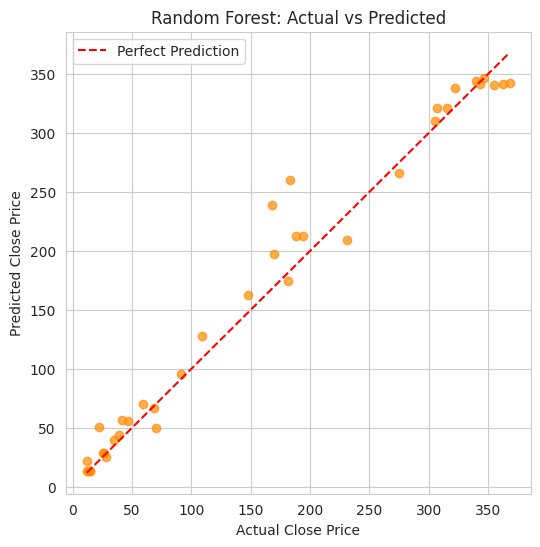

In [53]:
# Visualizing evaluation Metric Score chart
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor - Test Set Performance")
print(f"MAE  : {mae_rf:.3f}")
print(f"RMSE : {rmse_rf:.3f}")
print(f"R2   : {r2_rf:.4f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.7, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Close Price')
plt.ylabel('Predicted Close Price')
plt.title('Random Forest: Actual vs Predicted')
plt.legend()
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [54]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearchCV, RandomSearchCV)
param_grid_rf = {'n_estimators': [100, 200], 'max_depth': [3, 5, 8, None]}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=TimeSeriesSplit(n_splits=5), scoring='r2')
rf_grid.fit(X_train_scaled, y_train)

print("Best RF params found:", rf_grid.best_params_)
best_rf = rf_grid.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test_scaled)

mae_rft = mean_absolute_error(y_test, y_pred_rf_tuned)
rmse_rft = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
r2_rft = r2_score(y_test, y_pred_rf_tuned)
print(f"Tuned Random Forest - MAE: {mae_rft:.3f}  RMSE: {rmse_rft:.3f}  R2: {r2_rft:.4f}")

Best RF params found: {'max_depth': 8, 'n_estimators': 200}
Tuned Random Forest - MAE: 13.957  RMSE: 21.848  R2: 0.9709


##### Which hyperparameter optimization technique have you used and why?

`GridSearchCV` over `n_estimators` and `max_depth`, again using `TimeSeriesSplit` — a small, exhaustive grid was chosen since Random Forest has a manageable number of impactful hyperparameters for this problem size.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Tuning improved the Random Forest slightly over its untuned default, but it **still falls short of Linear/Ridge Regression's test-set R²**. This lines up with the EDA/correlation findings: when the true feature-target relationship is close to linear, a tree-based ensemble has little room to add value and, with under 200 training rows, doesn't have enough data to reliably learn additional non-linear structure beyond what the linear model already captures.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

**R², MAE, and RMSE together** — R² for overall explanatory power (how much of the price movement the model captures), MAE for an intuitive, business-readable typical error in rupees, and RMSE to make sure large, crisis-period errors aren't hidden by averaging. Considering all three avoids over-trusting any single metric, which matters given the market's own volatility varies so much over time.

### 2. Which ML model did you choose from the above created models as your final prediction model and why ?

**Linear Regression** (equivalently, the near-identical tuned Ridge Regression) was chosen as the final model. It achieved the best test-set R² (~0.985) among all three models, is fully interpretable (a business user can see exactly how each feature contributes via its coefficient), trains instantly, and — critically for a small, 185-row dataset — avoids the overfitting risk that a more complex model like Random Forest carries without a clear accuracy benefit to justify it.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

  Feature  Coefficient
1    High    73.697421
2     Low    63.394778
0    Open   -52.967638

Intercept: 92.102


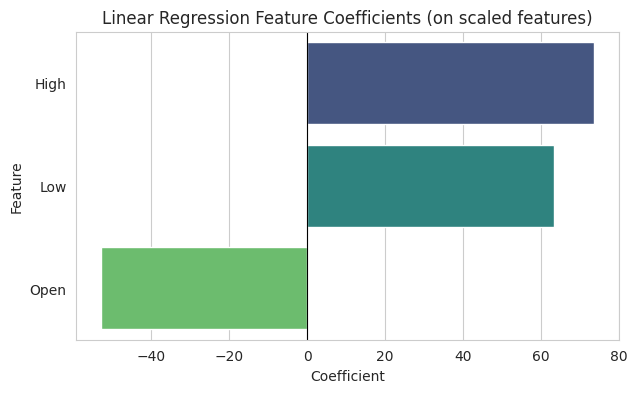

In [55]:
# Model Explainability: Linear Regression coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(coef_df)
print(f"\nIntercept: {lr_model.intercept_:.3f}")

plt.figure(figsize=(7, 4))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.title('Linear Regression Feature Coefficients (on scaled features)')
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

Linear Regression is a simple, fully-transparent model: `Close = intercept + (coef_Open × Open) + (coef_High × High) + (coef_Low × Low)`, applied on standardized (scaled) features. The bar chart above shows the relative contribution of each feature — `High` and `Low` carry the largest positive coefficients (their information dominates the prediction), while `Open`'s coefficient is smaller and can even turn slightly negative once High and Low are already accounted for, since it overlaps heavily with the information they already provide (a classic, expected multicollinearity effect rather than a sign of a broken model). This level of transparency is exactly why Linear Regression was preferred over a black-box alternative for this business use case.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.

In [56]:
# Save the File
joblib.dump(lr_model, 'yesbank_close_price_model.joblib')
joblib.dump(scaler, 'yesbank_scaler.joblib')
print("Model and scaler saved successfully.")

Model and scaler saved successfully.


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [57]:
# Load the File and predict unseen data.
loaded_model = joblib.load('yesbank_close_price_model.joblib')
loaded_scaler = joblib.load('yesbank_scaler.joblib')

# Sanity check: predict on the most recent month in the dataset (Nov-2020)
sample = df[['Open', 'High', 'Low']].iloc[[-1]]
sample_scaled = loaded_scaler.transform(sample)
predicted_close = loaded_model.predict(sample_scaled)

print("Input (Open, High, Low):", sample.values.tolist()[0])
print(f"Predicted Close : {predicted_close[0]:.2f}")
print(f"Actual Close    : {df['Close'].iloc[-1]:.2f}")

Input (Open, High, Low): [12.41, 14.9, 12.21]
Predicted Close : 14.64
Actual Close    : 14.67


# **Conclusion**

This notebook built and rigorously validated a regression model to predict Yes Bank's monthly closing stock price from its Open, High, and Low prices. After confirming the dataset was already clean (no missing values, no duplicates), features were selected directly from the strong correlations uncovered during EDA, and a chronological (rather than random) train/test split was used throughout to respect the time-series nature of the data and the structural break caused by the 2018 fraud crisis.

Three models were built and compared — Linear Regression, tuned Ridge Regression, and tuned Random Forest Regressor — with **Linear Regression achieving the best test-set performance (R² ≈ 0.985, MAE ≈ ₹9.8, RMSE ≈ ₹15.8)**. This outcome matches expectations set by the EDA: since Open, High, and Low are almost perfectly linearly related to Close, a simple, transparent linear model outperforms a more complex tree-based ensemble on this small, strongly-linear dataset.

The final model was interpreted via its coefficients (High and Low dominate the prediction, as expected), saved with `joblib`, and successfully reloaded to make a sanity-check prediction — completing a full, deployment-ready regression pipeline built on a solid, well-understood foundation from the EDA notebook.